# Step-by-step exercise

The proposed dataset collects the outcome of a survey for uncovering the satisfaction of airline passengers.

The **overall goal is to carry out a data mining process to predict passenger satisfaction**.

- Gender: Gender of the passengers (Female, Male)
- Customer Type: The customer type (Loyal customer, disloyal customer)
- Age: The actual age of the passengers
- Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)
- Flight distance: The flight distance of this journey
- Inflight wifi service: Satisfaction level of the inflight wifi service (0:N/A; 1 (bad) - 5 (good))
- Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient
- Ease of Online booking: Satisfaction level of online booking
- Gate location: Satisfaction level of Gate location
- Food and drink: Satisfaction level of Food and drink
- Online boarding: Satisfaction level of online boarding
- Seat comfort: Satisfaction level of Seat comfort
- Inflight entertainment: Satisfaction level of inflight entertainment
- On-board service: Satisfaction level of On-board service
- Leg room service: Satisfaction level of Leg room service
- Baggage handling: Satisfaction level of baggage handling
- Check-in service: Satisfaction level of Check-in service
- Inflight service: Satisfaction level of inflight service
- Cleanliness: Satisfaction level of Cleanliness
- Departure Delay in Minutes: Minutes delayed when departure
- Arrival Delay in Minutes: Minutes delayed when Arrival
- Satisfaction: Airline satisfaction level (Satisfaction, neutral or dissatisfaction)


# Task
- Carry out a **classification analysis** aimed at predicting **passenger satisfaction** considering the following setting:
    - Apply a 10-fold cross-validation procedure on the dataset (airline-train.csv) to identify the most suitable classifier among the following:
        - DecisionTree classifier (setting the maximum depth equal to 6)
        - KNearestNeighbor classifier (default params)
        - KNearestNeighbor classifier (default params) after feature selection targeted at keeping 10 features
    - Report and discuss the results, motivating the choice of the most suitable model
- Evaluate and discuss results on the test set:
    - Import the *airline-test.csv* test set
    - Report and discuss the results on the test set
* **Hints**:
    * Hint 1: leverage the insights from the previous notebook
    * Hint 2: use pipelines!

In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt

In [2]:
diz_class = {'Eco': 0,
             'Eco Plus': 1,
             'Business': 2}
diz_loyalty = {'Loyal Customer': 1,
               'disloyal Customer': 0}
diz_gender = {'Male': 1,
              'Female': 0}
diz_type = {'Personal Travel': 0,
            'Business travel': 1}

In [3]:
def extract_x_y(filename):
    # Here we perform all the "cleaning" steps. 
    # We assume that this transformation can be safely applied both on the training and test sets.
    df = pd.read_csv(os.path.join('dataset', filename), index_col=0)
    df = df.drop(['id', 'Arrival Delay in Minutes'], axis = 1)
    
    df['Class'] = df['Class'].apply(lambda x: diz_class[x])
    df['Customer Type'] = df['Customer Type'].apply(lambda x: diz_loyalty[x])
    df['Gender'] = df['Gender'].apply(lambda x: diz_gender[x])
    df['Type of Travel'] = df['Type of Travel'].apply(lambda x: diz_type[x])
    
    numerical_variables = ['Age',
                           'Flight Distance',
                           'Departure Delay in Minutes']
    nominal_variables = ['Gender',
                         'Customer Type', 
                         'Type of Travel', 
                         'Class']
    ordinal_variables = list(set(df.columns) - set(numerical_variables + nominal_variables + ['satisfaction']))
    
    df[ordinal_variables] = df[ordinal_variables].replace(0, np.nan)
    
    X = df.drop('satisfaction', axis = 1)
    y = df['satisfaction']
    
    return X, y
    
X_tr, y_tr = extract_x_y('airline-train.csv')
X_te, y_te = extract_x_y('airline-test.csv')

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, make_scorer, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 123)

In [6]:
def eval_cross_validation(pipeline, X, y):
    list_df = []
    list_accuracy = []
    for train, val in skf.split(X, y):
        # fit and predict using pipeline
        X_tr = X.values[train]
        y_tr = y.values[train]
        X_val = X.values[val]
        y_val = y.values[val]
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        # compute classification report
        cr = classification_report(y_val, y_pred, output_dict = True, zero_division = np.nan)
        # store accuracy
        list_accuracy.append(cr['accuracy'])
        # store per-class metrics as a dataframe
        df = pd.DataFrame({k: v for k, v in cr.items() if k != 'accuracy'})
        list_df.append(df)
    
    # compute average per-class metrics    
    df_concat = pd.concat(list_df)
    by_row_index = df_concat.groupby(df_concat.index)
    df_avg = by_row_index.mean().round(3)

    # compute average accuracy
    accuracy_avg = np.mean(list_accuracy)
    
    return df_avg, accuracy_avg 

accuracy 0.9144594849563028


,neutral or dissatisfied,satisfied,macro avg,weighted avg
f1-score,0.924,0.902,0.913,0.914
precision,0.926,0.900,0.913,0.915
recall,0.923,0.903,0.913,0.914
support,5887.900,4502.500,10390.400,10390.400


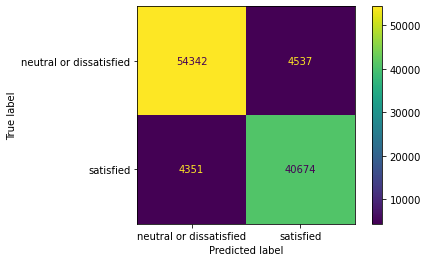

In [7]:
estimators = [('missing', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
              ('clf', DecisionTreeClassifier(random_state = 123, max_depth = 6))]
pipe = Pipeline(estimators)
df_metrics, acc = eval_cross_validation(pipe, X_tr, y_tr)

print('accuracy', acc)
display(df_metrics)
y_pred = cross_val_predict(pipe, X_tr, y_tr, cv = skf)
ConfusionMatrixDisplay.from_predictions(y_tr, y_pred)
plt.show()

In [8]:
# save CV scores for further processing
r_dt = cross_val_score(pipe, 
                       X_tr, 
                       y_tr, 
                       scoring = make_scorer(f1_score, average = 'macro', pos_label = 'neutral or dissatisfied'),
                       cv = skf)

/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_

accuracy 0.9256236781867481


,neutral or dissatisfied,satisfied,macro avg,weighted avg
f1-score,0.936,0.911,0.924,0.925
precision,0.913,0.944,0.929,0.927
recall,0.960,0.880,0.920,0.926
support,5887.900,4502.500,10390.400,10390.400


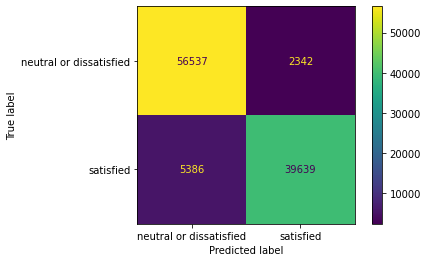

In [9]:
estimators = [('missing', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
              ('scaler', StandardScaler()),
              ('clf', KNeighborsClassifier())]
pipe = Pipeline(estimators)
df_metrics, acc = eval_cross_validation(pipe, X_tr, y_tr)
print('accuracy', acc)
display(df_metrics)
y_pred = cross_val_predict(pipe, X_tr, y_tr, cv = skf)
ConfusionMatrixDisplay.from_predictions(y_tr, y_pred, values_format = '')
plt.show()

In [10]:
# save CV scores for further processing
r_knn = cross_val_score(pipe, 
                        X_tr, 
                        y_tr, 
                        scoring = make_scorer(f1_score, average = 'macro', pos_label = 'neutral or dissatisfied'),
                        cv = skf)

/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_

accuracy 0.92034957141133


,neutral or dissatisfied,satisfied,macro avg,weighted avg
f1-score,0.931,0.906,0.919,0.92
precision,0.917,0.925,0.921,0.92
recall,0.945,0.888,0.917,0.92
support,5887.900,4502.500,10390.400,10390.40


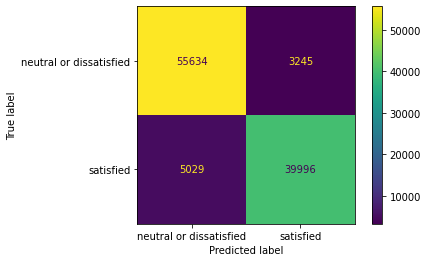

In [11]:
estimators = [('missing', SimpleImputer(missing_values=np.nan, strategy = 'most_frequent')),
              ('scaler', StandardScaler()),
              ('fsel', SelectKBest(f_classif, k = 10)),
              ('clf', KNeighborsClassifier())]
pipe = Pipeline(estimators)
df_metrics, acc = eval_cross_validation(pipe, X_tr, y_tr)
print('accuracy', acc)
display(df_metrics)
y_pred = cross_val_predict(pipe, 
                           X_tr, 
                           y_tr, 
                           cv=skf)
ConfusionMatrixDisplay.from_predictions(y_tr, y_pred, values_format = '')
plt.show()


In [12]:
make_scorer(f1_score, average = 'macro')

make_scorer(f1_score, average=macro)

In [13]:
r_knn_fsel = cross_val_score(pipe, 
                             X_tr, 
                             y_tr, 
                             scoring = make_scorer(f1_score, average = 'macro', pos_label = 'neutral or dissatisfied'),
                             cv = skf)

/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'neutral or dissatisfied') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/home/fabrizio/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_

## Statistical Test

In [14]:
df_results = pd.DataFrame({'dt': r_dt, 
                           'knn': r_knn, 
                           'knn_fsel': r_knn_fsel})
df_results 


,dt,knn,knn_fsel
0,0.911403,0.923386,0.916113
1,0.914860,0.925454,0.924765
2,0.914194,0.924537,0.916563
3,0.913073,0.918212,0.914568
4,0.914883,0.927137,0.920898
5,0.908613,0.924773,0.917394
6,0.914836,0.922274,0.917841
7,0.912806,0.925120,0.920887
8,0.914252,0.924354,0.919488
9,0.910605,0.920763,0.916719


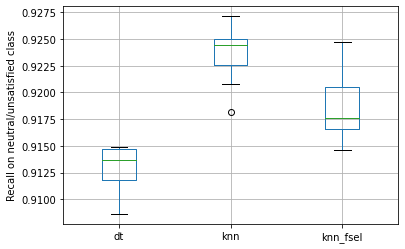

In [15]:
bplot = df_results.boxplot()
bplot.set_ylabel('Recall on neutral/unsatisfied class')
plt.show()

In [16]:
from scipy.stats import wilcoxon

In [17]:
wilcoxon(df_results.dt, df_results.knn)

WilcoxonResult(statistic=0.0, pvalue=0.001953125)

In [18]:
wilcoxon(df_results.knn_fsel, df_results.knn)

WilcoxonResult(statistic=0.0, pvalue=0.001953125)

In [19]:
wilcoxon(df_results.knn_fsel, df_results.dt)

WilcoxonResult(statistic=0.0, pvalue=0.001953125)

Given the confidence level $\alpha = 0.05 $, we can conclude that, since ***p*-value $ < \alpha$**, the null hypothesis (that the two related paired samples come from the same distribution) **can be rejected**. 

We can conclude that the classification pipeline with knn can be regarded as the most suitable one, in terms of the chosen classification metric (macro f1 score).


# Results on test-set

In [20]:
estimators = [('missing', SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')),
              ('scaler', StandardScaler()),
              ('clf', KNeighborsClassifier())]
pipe = Pipeline(estimators)
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

In [21]:
print(classification_report(y_te, y_pred))

                         precision    recall  f1-score   support

neutral or dissatisfied       0.91      0.96      0.94     14573
              satisfied       0.94      0.89      0.91     11403

               accuracy                           0.93     25976
              macro avg       0.93      0.92      0.92     25976
           weighted avg       0.93      0.93      0.93     25976



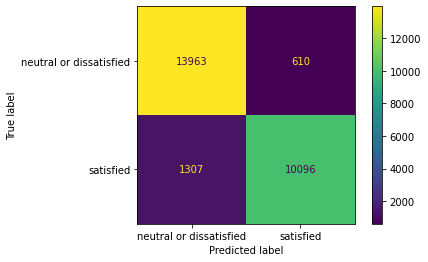

In [22]:
ConfusionMatrixDisplay.from_predictions(y_te, y_pred,values_format = '')
plt.show()

In [23]:
from sklearn.metrics import RocCurveDisplay

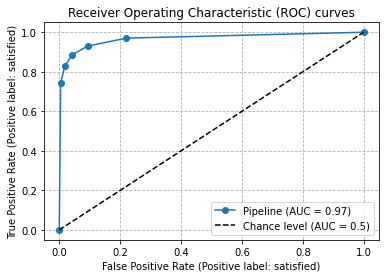

In [24]:
RocCurveDisplay.from_estimator(pipe, 
                               X_te, 
                               y_te, 
                               pos_label = 'satisfied', 
                               plot_chance_level=True, marker = 'o')
plt.title("Receiver Operating Characteristic (ROC) curves")
plt.grid(linestyle="--")
plt.show()

We notice that ...
